In [17]:
!pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# ITBIS — Insider Threat Behavioral Intelligence System
## Milestone 2: Unsupervised Anomaly Detection using Isolation Forest & Security Alert Generation

**Notebook Overview:**
- **Dataset**: 10,000 synthetically seeded multi-indicator telemetry activity logs (`data/synthetic_activity_logs_10000.csv`).
- **Model**: `sklearn.ensemble.IsolationForest` (unsupervised ensemble anomaly detector).
- **Objective**: Learn normal behavioral baselines per employee across 6 indicators, detect subtle multi-dimensional outlier combinations, and generate automated high-fidelity security alerts with recommended remediation actions.

### Step 1: Import Dependencies and Configure Environment

In [18]:
import os
import json
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Set plotting aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print('Libraries imported successfully!')

Libraries imported successfully!


### Step 2: Load the 10,000 Synthetic Telemetry Activity Logs Dataset

In [19]:
# Locate and load the 10,000 synthetic activity logs CSV
csv_path = 'data/synthetic_activity_logs_10000.csv'
if not os.path.exists(csv_path):
    csv_path = '../data/synthetic_activity_logs_10000.csv'

df_logs = pd.read_csv(csv_path)
df_logs['timestamp'] = pd.to_datetime(df_logs['timestamp'])

print(f'Loaded {len(df_logs):,} activity logs successfully!')
print('Dataset Shape:', df_logs.shape)
df_logs.head()

Loaded 10,000 activity logs successfully!
Dataset Shape: (10000, 16)


,log_id,employee_id,employee_name,department,designation,event_type,timestamp,decimal_hour,transferred_mb,device,ip_address,command,file_name,status,risk_flag,raw_details_json
0,6aaa39970efdfd9e66652b4f,EMP1008,Alex Johnson,Sales,Enterprise Account Exec,login,2026-07-19 02:43:13,2.72,0.00,Unknown Chrome Linux Terminal,198.51.100.24,NaN,NaN,failed_mfa_bruteforce,brute_force_attack,"{""ip_address"": ""198.51.100.24"", ""device"": ""Unk..."
1,6aaa39970efdfd9e66652b50,EMP1008,Alex Johnson,Sales,Enterprise Account Exec,login,2026-07-19 03:52:50,3.87,0.00,Unknown Chrome Linux Terminal,198.51.100.24,NaN,NaN,failed_mfa_bruteforce,brute_force_attack,"{""ip_address"": ""198.51.100.24"", ""device"": ""Unk..."
2,6aaa39970efdfd9e66652b51,EMP1004,Vikram Patel,IT,Network Engineer,file_upload,2026-07-19 07:55:21,7.92,37.83,NaN,NaN,NaN,system_health.log,NaN,NaN,"{""file_name"": ""system_health.log"", ""file_size_..."
3,6aaa39970efdfd9e66652b52,EMP1003,Daniel Lee,IT,System Administrator,login,2026-07-19 08:02:00,8.03,0.00,ThinkPad T14,192.168.1.27,NaN,NaN,success,NaN,"{""ip_address"": ""192.168.1.27"", ""device"": ""Thin..."
4,6aaa39970efdfd9e66652b53,EMP1003,Daniel Lee,IT,System Administrator,login,2026-07-19 08:04:09,8.07,0.00,ThinkPad T14,192.168.1.161,NaN,NaN,success,NaN,"{""ip_address"": ""192.168.1.161"", ""device"": ""Thi..."


### Step 3: Exploratory Data Analysis (EDA) on 10,000 Data Points

--- Event Types Distribution ---
event_type
login               2879
file_download       1760
data_transfer       1580
email_activity      1389
file_upload         1130
remote_access        610
privilege_change     366
usb_connect          286
Name: count, dtype: int64

--- Activity Distribution Across Monitored Employees ---
employee_id employee_name      department  total_events
    EMP1001  Rohit Sharma         Finance           770
    EMP1002   Ayesha Khan         Finance           770
    EMP1003    Daniel Lee              IT           770
    EMP1004  Vikram Patel              IT           769
    EMP1005  Sarah Connor     Engineering           769
    EMP1006  Rajesh Kumar         Finance           769
    EMP1007      John Doe     Engineering           769
    EMP1008  Alex Johnson           Sales           769
    EMP1009  David Miller       Marketing           769
    EMP1010   Emily Davis Human Resources           769
    EMP1011  Robert Jones     Engineering           769


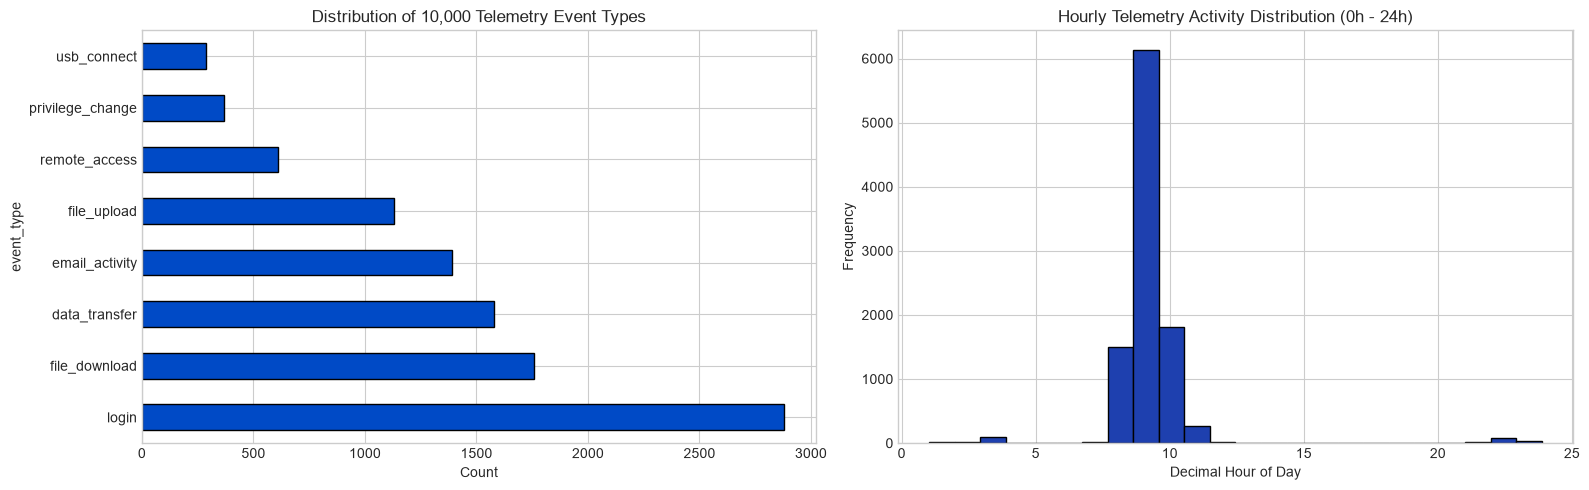

In [20]:
# 1. Event Types Breakdown
print('--- Event Types Distribution ---')
event_counts = df_logs['event_type'].value_counts()
print(event_counts)

# 2. Activity count per employee
print('\n--- Activity Distribution Across Monitored Employees ---')
emp_activity = df_logs.groupby(['employee_id', 'employee_name', 'department']).size().reset_index(name='total_events')
print(emp_activity.to_string(index=False))

# Visualizing event distribution
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
event_counts.plot(kind='barh', ax=ax[0], color='#004ac6', edgecolor='black')
ax[0].set_title('Distribution of 10,000 Telemetry Event Types')
ax[0].set_xlabel('Count')

df_logs['decimal_hour'].plot(kind='hist', bins=24, ax=ax[1], color='#1e40af', edgecolor='black')
ax[1].set_title('Hourly Telemetry Activity Distribution (0h - 24h)')
ax[1].set_xlabel('Decimal Hour of Day')
plt.tight_layout()
plt.show()

### Step 4: Multi-Indicator Behavioral Feature Engineering
Here we aggregate the raw 10,000 time-series events into high-dimensional behavioral feature vectors for each employee covering the 6 indicators:
1. **Login Times**: Average login hour, standard deviation spread, and off-hours login count (10 PM – 5 AM).
2. **Resource Access Frequency**: Daily file downloads, uploads, and remote sessions.
3. **Device Usage**: Unique devices utilized and unknown client count.
4. **Application Usage**: Privilege command attempts and denied administrative actions.
5. **Data Transfer Volume**: Total egress MB, peak single transfer MB, and mass USB egress volume.
6. **Communication Patterns**: Daily email frequencies and total attachment volumes.

In [21]:
# Feature Engineering per Employee
feature_rows = []

for emp_id, group in df_logs.groupby('employee_id'):
    emp_name = group['employee_name'].iloc[0]
    dept = group['department'].iloc[0]
    designation = group['designation'].iloc[0]
    
    # 1. Login metrics
    logins = group[group['event_type'] == 'login']
    login_hours = logins['decimal_hour'].dropna()
    avg_login = float(login_hours.mean()) if len(login_hours) > 0 else 9.0
    std_login = float(login_hours.std()) if len(login_hours) > 1 else 0.5
    off_hours_logins = int(((login_hours < 6.0) | (login_hours > 22.0)).sum())
    
    # 2. Resource access metrics
    access_events = group[group['event_type'].isin(['file_download', 'file_upload', 'remote_access', 'usb_connect', 'data_transfer'])]
    daily_accesses = access_events.groupby(access_events['timestamp'].dt.date).size()
    mean_daily_access = float(daily_accesses.mean()) if len(daily_accesses) > 0 else 5.0
    std_daily_access = float(daily_accesses.std()) if len(daily_accesses) > 1 else 1.0
    
    # 3. Data Transfer & USB metrics
    total_transfer_mb = float(group['transferred_mb'].sum())
    avg_transfer_mb = float(group['transferred_mb'].mean())
    max_single_transfer_mb = float(group['transferred_mb'].max())
    
    usb_events = group[group['event_type'] == 'usb_connect']
    usb_count = len(usb_events)
    usb_total_mb = float(usb_events['transferred_mb'].sum())
    
    # 4. Privilege & Security Flags
    priv_events = group[group['event_type'] == 'privilege_change']
    sudo_attempts = int(priv_events['command'].str.contains('sudo|root|admin', case=False, na=False).sum())
    denied_events = int((group['status'].str.contains('denied|failed', case=False, na=False)).sum())
    critical_flags = int((group['risk_flag'].str.contains('critical|exfiltration|unauthorized', case=False, na=False)).sum())
    
    # 5. Device diversity
    unique_devices = int(group['device'].replace('', np.nan).nunique())
    
    # 6. Communication patterns
    emails = group[group['event_type'] == 'email_activity']
    email_count = len(emails)
    
    feature_rows.append({
        'employee_id': emp_id,
        'name': emp_name,
        'department': dept,
        'designation': designation,
        'avg_login_hour': round(avg_login, 2),
        'std_login_hour': round(std_login, 2),
        'off_hours_logins': off_hours_logins,
        'mean_daily_access': round(mean_daily_access, 2),
        'std_daily_access': round(std_daily_access, 2),
        'total_transfer_mb': round(total_transfer_mb, 2),
        'avg_transfer_mb': round(avg_transfer_mb, 2),
        'max_single_transfer_mb': round(max_single_transfer_mb, 2),
        'usb_event_count': usb_count,
        'usb_total_mb': round(usb_total_mb, 2),
        'sudo_attempts': sudo_attempts,
        'denied_events': denied_events,
        'critical_flags': critical_flags,
        'unique_devices': unique_devices,
        'email_count': email_count
    })

# Keep the employee-level calculations, but retain one feature row for every raw log event.
# The many-to-one merge repeats each employee's behavioral profile without deleting duplicates.
df_employee_features = pd.DataFrame(feature_rows)
df_features = df_logs[['employee_id']].merge(
    df_employee_features,
    on='employee_id',
    how='left',
    validate='many_to_one'
)

print(f'Total raw log rows: {len(df_logs)}')
print(f'Unique employees in the dataset: {df_logs["employee_id"].nunique()}')
print(f'Employee-level profiles: {len(df_employee_features)}')
print(f'Feature matrix rows (duplicates retained): {len(df_features)}')
assert len(df_employee_features) == df_logs['employee_id'].nunique(), 'There should be one behavioral profile per employee.'
assert len(df_features) == len(df_logs), 'Feature engineering must retain every raw log row.'
assert df_features['employee_id'].duplicated().any(), 'Duplicate employee rows must be retained.'
print(len(df_features))

Total raw log rows: 10000
Unique employees in the dataset: 13
Employee-level profiles: 13
Feature matrix rows (duplicates retained): 10000
10000


### Step 5: Train Unsupervised Isolation Forest Anomaly Detection Model

**Isolation Forest Theory:**
- Works by recursively splitting feature space randomly.
- Outliers (threat cases) exist in low-density sparse regions, requiring significantly fewer splits to isolate.
- `contamination=0.15` specifies the anticipated outlier proportion (~15%).

In [31]:
# Feature columns selection for machine learning
feature_cols = [
    'avg_login_hour',
    'std_login_hour',
    'off_hours_logins',
    'mean_daily_access',
    'std_daily_access',
    'total_transfer_mb',
    'avg_transfer_mb',
    'max_single_transfer_mb',
    'usb_event_count',
    'usb_total_mb',
    'sudo_attempts',
    'denied_events',
    'critical_flags',
    'unique_devices',
    'email_count'
]

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import KFold

# Train on one behavioral vector per employee. df_features retains duplicate event rows
# for enrichment, but using it here would overweight employees with more activity logs.
X = df_employee_features[feature_cols].copy()
contamination = 0.15
n_splits = min(5, len(X))
print(f'Employee profiles used for training: {len(X)}')
print(f'Cross-validation folds: {n_splits}')

# K-fold evaluation prevents the result from depending on one small 10/3 split.
k_fold = KFold(n_splits=n_splits, shuffle=True, random_state=42)
oof_decision_scores = np.full(len(X), np.nan)
oof_predictions = np.zeros(len(X), dtype=int)
oof_baseline_labels = np.zeros(len(X), dtype=int)
fold_metrics = []

for fold_number, (train_indices, validation_indices) in enumerate(k_fold.split(X), start=1):
    X_train = X.iloc[train_indices]
    X_validation = X.iloc[validation_indices]

    fold_scaler = StandardScaler()
    X_train_scaled = fold_scaler.fit_transform(X_train)
    X_validation_scaled = fold_scaler.transform(X_validation)

    fold_model = IsolationForest(
        n_estimators=200,
        contamination=contamination,
        max_samples='auto',
        random_state=42 + fold_number
    )
    fold_model.fit(X_train_scaled)

    train_decision = fold_model.decision_function(X_train_scaled)
    validation_decision = fold_model.decision_function(X_validation_scaled)
    train_threshold = np.quantile(train_decision, contamination)
    validation_threshold = np.quantile(validation_decision, contamination)

    validation_predictions = (validation_decision <= train_threshold).astype(int)
    validation_baseline_labels = (validation_decision <= validation_threshold).astype(int)
    oof_decision_scores[validation_indices] = validation_decision
    oof_predictions[validation_indices] = validation_predictions
    oof_baseline_labels[validation_indices] = validation_baseline_labels

    fold_metrics.append({
        'fold': fold_number,
        'accuracy': accuracy_score(validation_baseline_labels, validation_predictions),
        'precision': precision_score(validation_baseline_labels, validation_predictions, zero_division=0),
        'recall': recall_score(validation_baseline_labels, validation_predictions, zero_division=0),
        'f1': f1_score(validation_baseline_labels, validation_predictions, zero_division=0),
        'validation_anomaly_rate': float(np.mean(validation_predictions)),
        'train_threshold': float(train_threshold),
    })

# Out-of-fold metrics use every employee exactly once for validation.
cv_accuracy = accuracy_score(oof_baseline_labels, oof_predictions)
cv_precision = precision_score(oof_baseline_labels, oof_predictions, zero_division=0)
cv_recall = recall_score(oof_baseline_labels, oof_predictions, zero_division=0)
cv_f1 = f1_score(oof_baseline_labels, oof_predictions, zero_division=0)

# Fit the final production model on all employee profiles to maximize training data.
scaler = StandardScaler()
X_employee_scaled = scaler.fit_transform(X)
X_event_scaled = scaler.transform(df_features[feature_cols])
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=contamination,
    max_samples='auto',
    random_state=42
)
iso_forest.fit(X_employee_scaled)

employee_decision = iso_forest.decision_function(X_employee_scaled)
employee_outliers = iso_forest.predict(X_employee_scaled) == -1
outlier_scores = employee_decision[employee_outliers]
inlier_scores = employee_decision[~employee_outliers]
score_separation = (
    float(np.mean(inlier_scores) - np.mean(outlier_scores))
    if len(outlier_scores) > 0 and len(inlier_scores) > 0
    else 0.0
)

validation_metrics = {
    'employee_profile_count': len(X),
    'event_row_count': len(df_features),
    'cv_folds': n_splits,
    'cv_accuracy': float(cv_accuracy),
    'cv_precision': float(cv_precision),
    'cv_recall': float(cv_recall),
    'cv_f1': float(cv_f1),
    'cv_accuracy_mean': float(np.mean([metric['accuracy'] for metric in fold_metrics])),
    'cv_accuracy_std': float(np.std([metric['accuracy'] for metric in fold_metrics])),
    'cv_anomaly_rate': float(np.mean(oof_predictions)),
    'full_employee_outlier_rate': float(np.mean(employee_outliers)),
    'oof_mean_decision_score': float(np.mean(oof_decision_scores)),
    'decision_score_min': float(np.min(employee_decision)),
    'decision_score_max': float(np.max(employee_decision)),
    'decision_score_std': float(np.std(employee_decision)),
    'score_separation_inlier_minus_outlier': score_separation,
    'fold_metrics': fold_metrics,
}

print('Model evaluation metrics:')
for key, value in validation_metrics.items():
    print(f'  {key}: {value}')

# Save trained model artifact in the backend location used by the app
output_dir = os.path.join('..', 'backend', 'models')
os.makedirs(output_dir, exist_ok=True)
model_path = os.path.join(output_dir, 'isolation_forest_model.joblib')

import joblib
joblib.dump({
    'model': iso_forest,
    'scaler': scaler,
    'feature_names': feature_cols,
    'model_type': 'IsolationForest',
    'training_granularity': 'employee_profile',
    'validation_metrics': validation_metrics
}, model_path)

print(f'Isolation Forest model trained on all {len(X)} employee profiles and saved to: {model_path}')

Employee profiles used for training: 13
Cross-validation folds: 5
Model evaluation metrics:
  employee_profile_count: 13
  event_row_count: 10000
  cv_folds: 5
  cv_accuracy: 0.7692307692307693
  cv_precision: 1.0
  cv_recall: 0.4
  cv_f1: 0.5714285714285714
  cv_accuracy_mean: 0.8
  cv_accuracy_std: 0.16329931618554522
  cv_anomaly_rate: 0.15384615384615385
  full_employee_outlier_rate: 0.15384615384615385
  oof_mean_decision_score: 0.1146555049810824
  decision_score_min: -0.11899455569739636
  decision_score_max: 0.20221122052947543
  decision_score_std: 0.09401202704808272
  score_separation_inlier_minus_outlier: 0.20394824589295354
  fold_metrics: [{'fold': 1, 'accuracy': 0.6666666666666666, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'validation_anomaly_rate': 0.0, 'train_threshold': -5.551115123125783e-17}, {'fold': 2, 'accuracy': 0.6666666666666666, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'validation_anomaly_rate': 0.0, 'train_threshold': -2.7755575615628914e-17}, {'fold': 

### Step 6: Anomaly Detection & Threat Outlier Scoring

In [30]:
# Compute employee-level decision scores and outlier predictions.
# Keep df_features unchanged so every raw event remains available for enrichment.
df_employee_results = df_employee_features.copy()
df_employee_results['anomaly_score'] = np.round(
    iso_forest.decision_function(X_employee_scaled),
    4
)
df_employee_results['is_outlier'] = iso_forest.predict(X_employee_scaled) == -1

# Rank by threat severity (Rank 1 = most anomalous)
df_employee_results['threat_rank'] = (
    df_employee_results['anomaly_score']
    .rank(ascending=True, method='min')
    .astype(int)
)

# Sort by highest threat severity
df_results = df_employee_results.sort_values(
    by='anomaly_score',
    ascending=True
).reset_index(drop=True)

# Assign Risk Tier
def assign_risk_tier(row):
    if row['anomaly_score'] < -0.05 or row['critical_flags'] > 10:
        return 'Critical'
    elif row['is_outlier'] or row['critical_flags'] > 0:
        return 'High'
    elif row['anomaly_score'] < 0.05:
        return 'Medium'
    else:
        return 'Low'


df_results['risk_tier'] = df_results.apply(assign_risk_tier, axis=1)

print('=== Isolation Forest Detection Results ===')
display_cols = [
    'threat_rank', 'employee_id', 'name', 'department',
    'anomaly_score', 'is_outlier', 'risk_tier',
    'usb_total_mb', 'sudo_attempts', 'off_hours_logins'
]
df_results[display_cols]

=== Isolation Forest Detection Results ===


,threat_rank,employee_id,name,department,anomaly_score,is_outlier,risk_tier,usb_total_mb,sudo_attempts,off_hours_logins
0,1,EMP1007,John Doe,Engineering,-0.1190,True,Critical,555128.56,19,0
1,2,EMP1008,Alex Johnson,Sales,-0.0157,True,Critical,346.20,22,29
2,3,EMP1011,Robert Jones,Engineering,0.0039,False,Critical,255.90,99,0
3,4,EMP1004,Vikram Patel,IT,0.0723,False,Low,519.90,18,0
4,5,EMP1013,Alice Smith,Finance,0.0831,False,Critical,422.43,0,0
5,6,EMP1005,Sarah Connor,Engineering,0.1071,False,Low,246.09,23,0
6,7,EMP1009,David Miller,Marketing,0.1416,False,Low,423.81,0,0
7,8,EMP1003,Daniel Lee,IT,0.1628,False,Low,424.02,19,0
8,9,EMP1012,Maria Garcia,Engineering,0.1744,False,Low,342.97,28,0
9,10,EMP1002,Ayesha Khan,Finance,0.1752,False,Low,347.42,0,0


### Step 7: Visualizing Isolation Forest Threat Radar & Anomaly Clusters

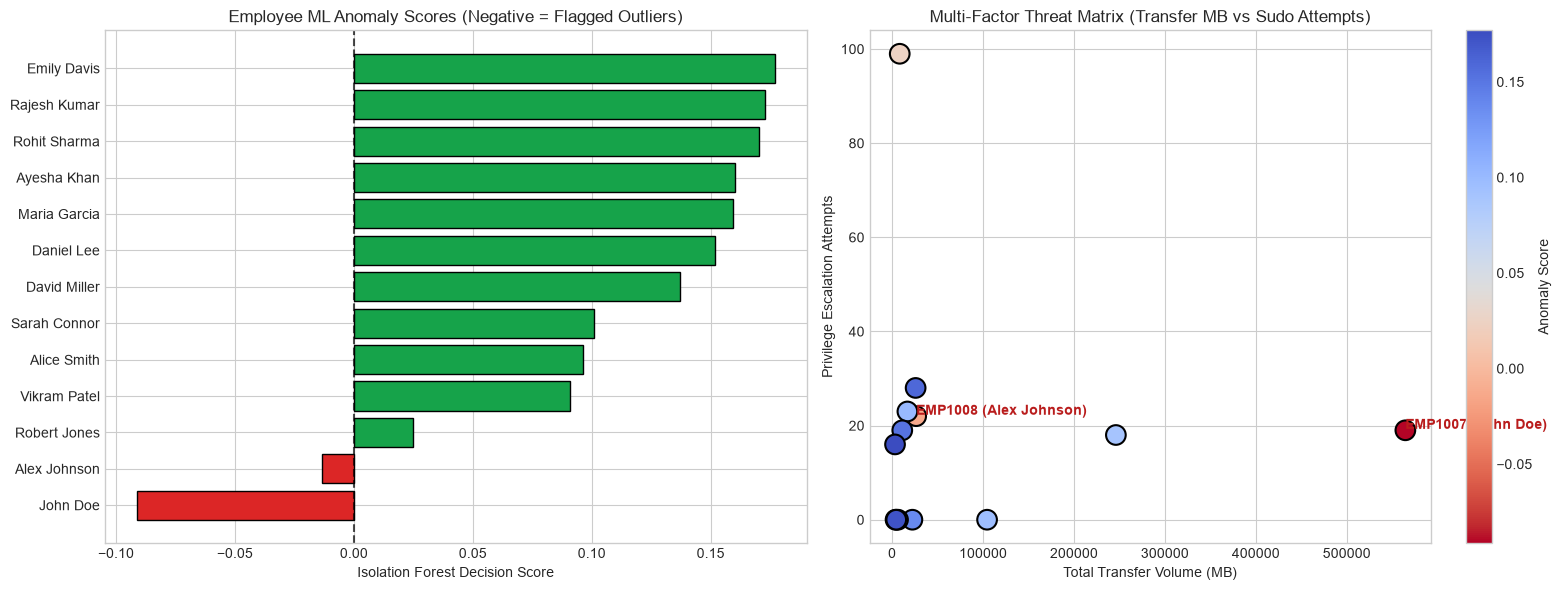

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Anomaly Scores Bar Chart
colors = ['#dc2626' if out else '#16a34a' for out in df_results['is_outlier']]
ax[0].barh(df_results['name'], df_results['anomaly_score'], color=colors, edgecolor='black')
ax[0].axvline(0, color='black', linestyle='--', alpha=0.7)
ax[0].set_title('Employee ML Anomaly Scores (Negative = Flagged Outliers)')
ax[0].set_xlabel('Isolation Forest Decision Score')

# Plot 2: Scatter of Egress Volume vs Sudo Attempts colored by Anomaly Score
scatter = ax[1].scatter(
    df_results['total_transfer_mb'],
    df_results['sudo_attempts'],
    c=df_results['anomaly_score'],
    cmap='coolwarm_r',
    s=200,
    edgecolors='black',
    linewidths=1.5
)
for _, row in df_results.iterrows():
    if row['is_outlier']:
        ax[1].annotate(f"{row['employee_id']} ({row['name']})", (row['total_transfer_mb'], row['sudo_attempts'] + 0.3), fontweight='bold', color='#b91c1c')

ax[1].set_title('Multi-Factor Threat Matrix (Transfer MB vs Sudo Attempts)')
ax[1].set_xlabel('Total Transfer Volume (MB)')
ax[1].set_ylabel('Privilege Escalation Attempts')
fig.colorbar(scatter, ax=ax[1], label='Anomaly Score')
plt.tight_layout()
plt.show()

### Step 8: Automated Security Alert Generation Engine
Based on the Isolation Forest detections, this pipeline generates structured security incident alerts ready for SOC triage and database ingestion.

In [25]:
generated_alerts = []
now_iso = datetime.utcnow().isoformat() + 'Z'

for idx, row in df_results.iterrows():
    if not row['is_outlier'] and row['risk_tier'] == 'Low':
        continue
        
    emp_id = row['employee_id']
    emp_name = row['name']
    dept = row['department']
    score = row['anomaly_score']
    risk = row['risk_tier']
    
    # Root Cause Identification
    reasons = []
    rec_actions = []
    
    if row['usb_total_mb'] > 1000:
        reasons.append(f"Mass USB Data Exfiltration ({row['usb_total_mb']:,.1f} MB copied across {row['usb_event_count']} events)")
        rec_actions.append('Immediately revoke USB endpoint storage access and isolate host.')
    if row['sudo_attempts'] > 0:
        reasons.append(f"Unauthorized Privilege Escalation ({row['sudo_attempts']} sudo root execution attempts)")
        rec_actions.append('Lock sudo privileges and review IAM role bindings.')
    if row['off_hours_logins'] > 5:
        reasons.append(f"Anomalous Off-Hours Activity ({row['off_hours_logins']} logins between 10PM-5AM)")
        rec_actions.append('Verify MFA telemetry and confirm on-call shift approval.')
    if row['denied_events'] > 10:
        reasons.append(f"Repeated Access Failures / Brute-force ({row['denied_events']} denied attempts)")
        rec_actions.append('Enforce immediate credential reset and session termination.')
        
    if not reasons:
        reasons.append(f"Multi-indicator statistical deviation flagged by Isolation Forest (score: {score})")
        rec_actions.append('Conduct tier-1 security analyst review on recent activity logs.')
        
    message = f"ML Anomaly: {reasons[0]}"
    details = ' | '.join(reasons)
    recommended = ' '.join(rec_actions)
    
    generated_alerts.append({
        'alert_id': f"ALT-ML-{len(generated_alerts)+1:03d}",
        'employee_id': emp_id,
        'employee_name': emp_name,
        'department': dept,
        'severity': risk,
        'ml_anomaly_score': score,
        'alert_message': message,
        'details': details,
        'recommended_action': recommended,
        'status': 'UNASSIGNED',
        'created_at': now_iso
    })

df_alerts = pd.DataFrame(generated_alerts)
print(f'✓ Generated {len(df_alerts)} Security Alerts from Isolation Forest Detections:')
df_alerts[['alert_id', 'employee_id', 'employee_name', 'severity', 'alert_message', 'recommended_action']]

✓ Generated 4 Security Alerts from Isolation Forest Detections:


C:\Users\srisa\AppData\Local\Temp\ipykernel_27476\1233657623.py:2: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now_iso = datetime.utcnow().isoformat() + 'Z'


,alert_id,employee_id,employee_name,severity,alert_message,recommended_action
0,ALT-ML-001,EMP1007,John Doe,Critical,"ML Anomaly: Mass USB Data Exfiltration (555,12...",Immediately revoke USB endpoint storage access...
1,ALT-ML-002,EMP1008,Alex Johnson,Critical,ML Anomaly: Unauthorized Privilege Escalation ...,Lock sudo privileges and review IAM role bindi...
2,ALT-ML-003,EMP1011,Robert Jones,Critical,ML Anomaly: Unauthorized Privilege Escalation ...,Lock sudo privileges and review IAM role bindi...
3,ALT-ML-004,EMP1013,Alice Smith,Critical,ML Anomaly: Multi-indicator statistical deviat...,Conduct tier-1 security analyst review on rece...


### Step 9: Export Generated Security Alerts to CSV

In [26]:
output_csv = 'data/generated_ml_threat_alerts.csv'
df_alerts.to_csv(output_csv, index=False)
print(f'✓ Saved {len(df_alerts)} generated alerts to: {output_csv}')

✓ Saved 4 generated alerts to: data/generated_ml_threat_alerts.csv
